# CS5720 Home Assignment 1

**Jeff Agnitsch** · Student ID: 7005146960 · Fall 2026

See `ROADMAP.md` for the phase-by-phase plan and concept notes.

In [1]:
# Shared imports and one fixed seed so every run (and the video) is reproducible
import os
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)      # seeds Python, NumPy, and TensorFlow together
os.makedirs("images", exist_ok=True)    # charts are saved here for the README

# Two fixed series colors used in every chart: blue = first series, orange = second
BLUE, ORANGE = "#2a78d6", "#eb6834"

print("TensorFlow", tf.__version__)
print("GPUs available:", len(tf.config.list_physical_devices("GPU")), "(CPU-only on native Windows)")

TensorFlow 2.21.0


GPUs available: 0 (CPU-only on native Windows)


## Task 1 — Tensor manipulation and reshaping

Goal: build a (4, 6) tensor, print rank/shape, reshape to (2, 3, 4), transpose to (3, 2, 4), broadcast a (1, 4) tensor onto it.

Why: shape bugs are the most common deep-learning bugs; this is the vocabulary for every layer that follows.

In [2]:
# --- Task 1: rank, shape, reshape, transpose, broadcast ---

def describe(name, x):
    """Print rank and shape using TensorFlow functions (tf.rank gives the number of axes)."""
    print(f"{name:<22} rank={int(tf.rank(x))}  shape={tuple(x.shape)}")

# 1. Random tensor of shape (4, 6), values uniform in [0, 1)
t = tf.random.uniform((4, 6))
describe("original", t)

# 2. Reshape to (2, 3, 4). Legal because 4*6 = 24 = 2*3*4.
#    Reshape keeps the elements in the same row-major order; it only regroups them.
r = tf.reshape(t, (2, 3, 4))
describe("reshaped (2,3,4)", r)

# 3. Transpose to (3, 2, 4). perm=[1, 0, 2] swaps axes 0 and 1 and keeps axis 2.
#    Unlike reshape, transpose actually moves data around.
p = tf.transpose(r, perm=[1, 0, 2])
describe("transposed (3,2,4)", p)

# 4. Broadcast a (1, 4) tensor onto (3, 2, 4) and add.
#    Aligning from the right: (1,4) -> padded to (1,1,4) -> stretched to (3,2,4).
small = tf.random.uniform((1, 4))
describe("small (1,4)", small)
added = p + small
describe("p + small", added)

# Prove the broadcast is the same as materialising the stretched tensor explicitly
explicit = tf.broadcast_to(small, p.shape)
print("broadcast_to shape:", tuple(explicit.shape),
      "| p + small == p + explicit:", bool(tf.reduce_all(added == p + explicit)))

# Counter-example: (1, 4) cannot broadcast against the ORIGINAL (4, 6) tensor,
# because the last axes are 4 vs 6 (neither equal nor 1).
try:
    t + small
except tf.errors.InvalidArgumentError as e:
    print("(4,6) + (1,4) fails as expected:", str(e).splitlines()[0])

original               rank=2  shape=(4, 6)
reshaped (2,3,4)       rank=3  shape=(2, 3, 4)
transposed (3,2,4)     rank=3  shape=(3, 2, 4)
small (1,4)            rank=2  shape=(1, 4)
p + small              rank=3  shape=(3, 2, 4)
broadcast_to shape: (3, 2, 4) | p + small == p + explicit: True
(4,6) + (1,4) fails as expected: {{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Incompatible shapes: [4,6] vs. [1,4] [Op:AddV2] name: 


### How broadcasting works in TensorFlow

Broadcasting lets TensorFlow combine tensors of different shapes without copying data. The shapes are compared **from the rightmost axis leftward**:

1. If one tensor has fewer axes, its shape is padded on the **left** with 1s.
2. Two axes are compatible when they are **equal** or **one of them is 1**.
3. Every axis of size 1 is treated as if it were repeated to match the other tensor. No copy is made; the same value is read for every position along that axis.

For this task: `(1, 4)` against `(3, 2, 4)` becomes `(1, 1, 4)`, then `1→3`, `1→2`, `4=4`, so the result is `(3, 2, 4)`. The same `(1, 4)` tensor fails against the original `(4, 6)` because the last axes are 4 and 6, which are neither equal nor 1. The counter-example in the cell above shows that error.

## Task 2 — Loss functions

Goal: compute MSE and categorical cross-entropy for the same `y_true` against several `y_pred` variants and chart them.

Why: the loss is what the optimizer minimizes; seeing how each loss reacts to the same prediction change explains why classifiers use cross-entropy.

In [3]:
# --- Task 2: MSE vs categorical cross-entropy on the same predictions ---

# True labels: 2 samples, 3 classes, one-hot. Sample 0 is class 2, sample 1 is class 1.
y_true = tf.constant([[0., 0., 1.],
                      [0., 1., 0.]])

def make_pred(p_correct):
    """Build a prediction that puts p_correct on the true class and splits the rest evenly.
    Each row sums to 1, so it looks like a softmax output."""
    p_other = (1.0 - p_correct) / 2.0
    return tf.constant([[p_other, p_other, p_correct],
                        [p_other, p_correct, p_other]])

# Start confident and correct, then move the probability mass away step by step
variants = {
    "confident (0.9)": make_pred(0.9),
    "slightly off (0.7)": make_pred(0.7),
    "unsure (0.5)": make_pred(0.5),
    "wrong (0.2)": make_pred(0.2),
}

mse = tf.keras.losses.MeanSquaredError()
cce = tf.keras.losses.CategoricalCrossentropy()

# Compute both losses for every variant and print them side by side
results = {}
print(f"{'prediction':<20} {'MSE':>8} {'CCE':>8}")
for name, y_pred in variants.items():
    m, c = float(mse(y_true, y_pred)), float(cce(y_true, y_pred))
    results[name] = (m, c)
    print(f"{name:<20} {m:>8.4f} {c:>8.4f}")

prediction                MSE      CCE
confident (0.9)        0.0050   0.1054
slightly off (0.7)     0.0450   0.3567
unsure (0.5)           0.1250   0.6931
wrong (0.2)            0.3200   1.6094


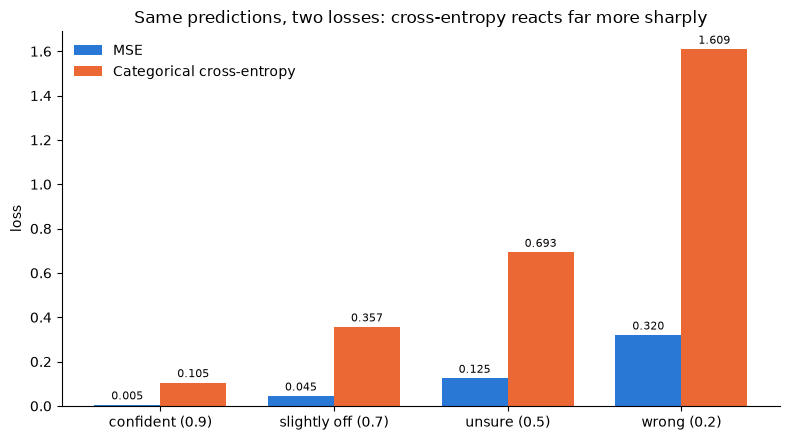

In [4]:
# Grouped bar chart: one group per prediction variant, one bar per loss
labels = list(results)
mse_vals = [results[k][0] for k in labels]
cce_vals = [results[k][1] for k in labels]
x = np.arange(len(labels))
w = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w / 2, mse_vals, w, label="MSE", color=BLUE)
b2 = ax.bar(x + w / 2, cce_vals, w, label="Categorical cross-entropy", color=ORANGE)
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
ax.set_xticks(x, labels)
ax.set_ylabel("loss")
ax.set_title("Same predictions, two losses: cross-entropy reacts far more sharply")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("images/losses.png", dpi=150)
plt.show()

**Interpretation.** Both losses rise as the correct-class probability drops, but not at the same rate. MSE is bounded (every term is a squared difference of probabilities) so it grows gently. Cross-entropy is `−log(p_correct)`, so it grows without bound as the model becomes confidently wrong. That steep gradient exactly when the model is most wrong is why classifiers train with cross-entropy rather than MSE.

## Task 3 — Adam vs SGD on MNIST

Goal: one model architecture, trained twice with only the optimizer changed; plot train/val accuracy per epoch for both.

Why: a controlled experiment. Change one variable, hold the rest fixed, compare.

In [5]:
# --- Task 3: load and preprocess MNIST ---
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Pixels are 0-255 integers; scale to 0-1 floats so the inputs are well-conditioned
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("train:", x_train.shape, y_train.shape, "| test:", x_test.shape, y_test.shape)
print("label range:", y_train.min(), "-", y_train.max())

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step

  393216/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

 1736704/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

 5963776/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


train: (60000, 28, 28) (60000,) | test: (10000, 28, 28) (10000,)
label range: 0 - 9


In [6]:
# --- Task 3: one model definition used for every run ---
EPOCHS = 5
BATCH = 128

def build_model():
    """Small dense network: 784 inputs -> 128 ReLU -> 10 softmax.
    Re-seeding before each build makes the initial weights identical across runs,
    so the optimizer is the only thing that differs."""
    tf.keras.utils.set_random_seed(42)
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),                       # 28x28 image -> 784 vector
        tf.keras.layers.Dense(128, activation="relu"),   # hidden layer
        tf.keras.layers.Dense(10, activation="softmax"), # one probability per digit
    ])

def train_with(optimizer, name):
    """Compile and train a fresh model with the given optimizer; return its history."""
    model = build_model()
    # sparse_categorical_crossentropy because labels are integers 0-9, not one-hot
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print(f"\n=== {name} ===")
    hist = model.fit(x_train, y_train, epochs=EPOCHS, batch_size=BATCH,
                     validation_split=0.1, verbose=2)   # hold out 10% of train as validation
    return hist

hist_adam = train_with(tf.keras.optimizers.Adam(), "Adam (lr=0.001, default)")
hist_sgd = train_with(tf.keras.optimizers.SGD(learning_rate=0.01), "SGD (lr=0.01, default)")


=== Adam (lr=0.001, default) ===
Epoch 1/5


422/422 - 1s - 2ms/step - accuracy: 0.8971 - loss: 0.3734 - val_accuracy: 0.9558 - val_loss: 0.1688


Epoch 2/5


422/422 - 0s - 1ms/step - accuracy: 0.9506 - loss: 0.1710 - val_accuracy: 0.9658 - val_loss: 0.1256


Epoch 3/5


...

422/422 - 0s - 960us/step - accuracy: 0.8827 - loss: 0.4559 - val_accuracy: 0.9117 - val_loss: 0.3556


Epoch 4/5


422/422 - 0s - 937us/step - accuracy: 0.8927 - loss: 0.4031 - val_accuracy: 0.9162 - val_loss: 0.3203


Epoch 5/5


422/422 - 0s - 961us/step - accuracy: 0.8986 - loss: 0.3717 - val_accuracy: 0.9205 - val_loss: 0.2979


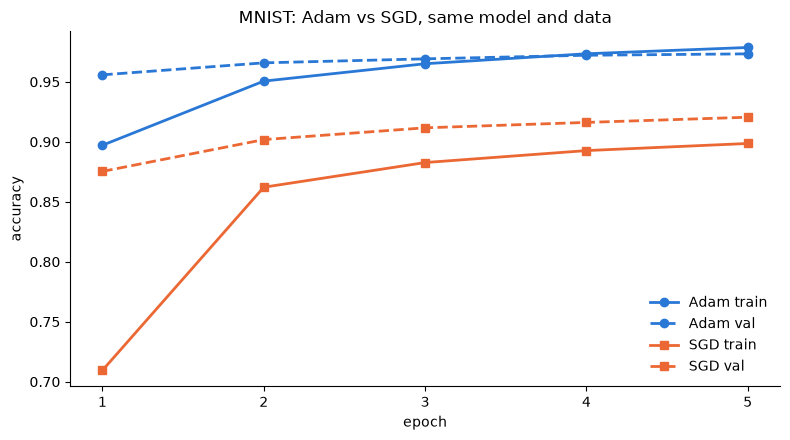

Adam: epoch-1 val acc = 0.9558, final val acc = 0.9733
SGD: epoch-1 val acc = 0.8753, final val acc = 0.9205


In [7]:
# Four lines on one axis: solid = training, dashed = validation; blue = Adam, orange = SGD
epochs = np.arange(1, EPOCHS + 1)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(epochs, hist_adam.history["accuracy"], color=BLUE, lw=2, marker="o", label="Adam train")
ax.plot(epochs, hist_adam.history["val_accuracy"], color=BLUE, lw=2, ls="--", marker="o", label="Adam val")
ax.plot(epochs, hist_sgd.history["accuracy"], color=ORANGE, lw=2, marker="s", label="SGD train")
ax.plot(epochs, hist_sgd.history["val_accuracy"], color=ORANGE, lw=2, ls="--", marker="s", label="SGD val")
ax.set_xticks(epochs)
ax.set_xlabel("epoch")
ax.set_ylabel("accuracy")
ax.set_title("MNIST: Adam vs SGD, same model and data")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("images/adam_vs_sgd.png", dpi=150)
plt.show()

for name, h in [("Adam", hist_adam), ("SGD", hist_sgd)]:
    print(f"{name}: epoch-1 val acc = {h.history['val_accuracy'][0]:.4f}, "
          f"final val acc = {h.history['val_accuracy'][-1]:.4f}")

**Interpretation.** Adam converged much faster. After one epoch it was already at 95.6% validation accuracy; SGD was at 87.5%. After five epochs Adam reached 97.3% and SGD 92.1%, and SGD's curve is still climbing, so it simply needs more epochs. The reason is how each optimizer turns a gradient into a step. SGD uses one fixed learning rate for every weight, and at 0.01 the steps are small. Adam keeps a running mean and variance of each weight's gradient and scales every step individually, so it moves quickly on flat directions and cautiously on steep ones without any tuning. This is a comparison of out-of-the-box defaults; SGD with a higher learning rate or with momentum would narrow the gap considerably.

## Task 4 — TensorBoard

Goal: train for 5 epochs with a TensorBoard callback writing to `logs/fit/<timestamp>`, then analyze the curves.

Why: TensorBoard is the standard tool for watching training live and spotting overfitting.

In [8]:
# --- Task 4: same model, logged to TensorBoard ---
# Each run gets its own timestamped folder so TensorBoard can overlay runs instead of overwriting
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

model = build_model()
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# validation_data = the held-out test set, so TensorBoard shows train vs validation curves
hist_tb = model.fit(x_train, y_train, epochs=5, batch_size=BATCH,
                    validation_data=(x_test, y_test),
                    callbacks=[tb_callback], verbose=2)

print("\nlogs written to:", log_dir)
print("launch with:  tensorboard --logdir logs/fit   then open http://localhost:6006")

Epoch 1/5


469/469 - 1s - 2ms/step - accuracy: 0.9038 - loss: 0.3478 - val_accuracy: 0.9472 - val_loss: 0.1809


Epoch 2/5


469/469 - 1s - 1ms/step - accuracy: 0.9553 - loss: 0.1576 - val_accuracy: 0.9620 - val_loss: 0.1291


Epoch 3/5


...

Epoch 4/5


469/469 - 1s - 1ms/step - accuracy: 0.9753 - loss: 0.0874 - val_accuracy: 0.9729 - val_loss: 0.0941


Epoch 5/5


469/469 - 1s - 1ms/step - accuracy: 0.9802 - loss: 0.0706 - val_accuracy: 0.9752 - val_loss: 0.0865



logs written to: logs\fit\20260914-202354
launch with:  tensorboard --logdir logs/fit   then open http://localhost:6006


To view the run, open a terminal in this folder with the venv active and run:

```
tensorboard --logdir logs/fit
```

then open http://localhost:6006 and go to the **Scalars** tab. (Inside Jupyter you can also run `%load_ext tensorboard` followed by `%tensorboard --logdir logs/fit`.) Screenshots of the accuracy and loss panels go in `images/`.

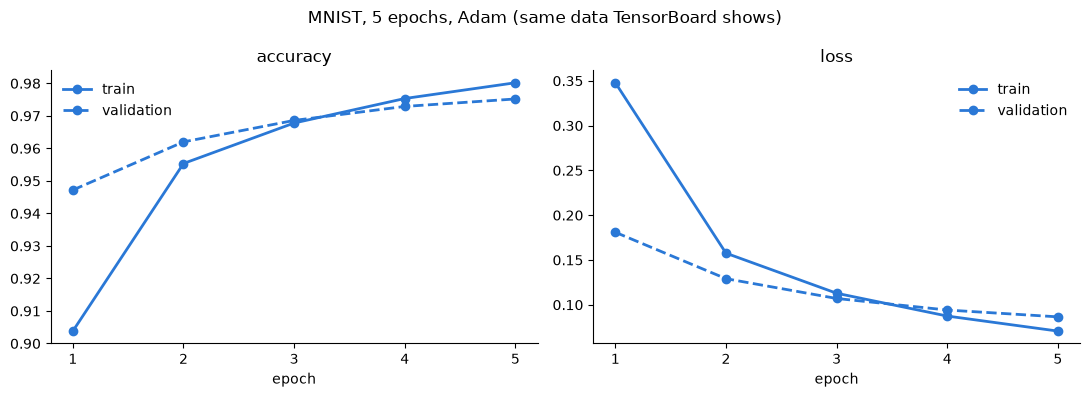

epoch 1: train acc 0.9038 | val acc 0.9472 | train loss 0.3478 | val loss 0.1809
epoch 2: train acc 0.9553 | val acc 0.9620 | train loss 0.1576 | val loss 0.1291
epoch 3: train acc 0.9678 | val acc 0.9686 | train loss 0.1129 | val loss 0.1070
epoch 4: train acc 0.9753 | val acc 0.9729 | train loss 0.0874 | val loss 0.0941
epoch 5: train acc 0.9802 | val acc 0.9752 | train loss 0.0706 | val loss 0.0865


In [9]:
# Backup plot of the same curves from the History object, for the README
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ep = np.arange(1, 6)
for ax, key, title in [(ax1, "accuracy", "accuracy"), (ax2, "loss", "loss")]:
    ax.plot(ep, hist_tb.history[key], color=BLUE, lw=2, marker="o", label="train")
    ax.plot(ep, hist_tb.history["val_" + key], color=BLUE, lw=2, ls="--", marker="o", label="validation")
    ax.set_xticks(ep)
    ax.set_xlabel("epoch")
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)
fig.suptitle("MNIST, 5 epochs, Adam (same data TensorBoard shows)")
fig.tight_layout()
fig.savefig("images/tensorboard_curves.png", dpi=150)
plt.show()

for i in range(5):
    print(f"epoch {i+1}: train acc {hist_tb.history['accuracy'][i]:.4f} | val acc {hist_tb.history['val_accuracy'][i]:.4f} | "
          f"train loss {hist_tb.history['loss'][i]:.4f} | val loss {hist_tb.history['val_loss'][i]:.4f}")

### 4.1 Answers

1. **Patterns in train vs validation accuracy.** Both curves rise every epoch and flatten out as they approach 98%. Training accuracy climbs from 90.4% to 98.0% and validation from 94.7% to 97.5%. In the first three epochs validation accuracy is actually *above* training accuracy. That is not a bug: the training number is averaged over a whole epoch while the weights are still improving, whereas validation is measured once at the end of the epoch with the finished weights. By epoch 4 the two lines cross and a small gap opens, with training slightly ahead. The loss panels show the same story in mirror image.

2. **Detecting overfitting in TensorBoard.** In the Scalars tab, put the train and validation curves for `epoch_loss` on the same plot. Overfitting shows up as a divergence: training loss keeps dropping while validation loss flattens and then starts to rise, and training accuracy keeps climbing while validation accuracy stalls. The widening gap between the two curves is the signal, and the epoch where validation loss bottoms out is where training should have stopped. The Histograms tab is a secondary check: weights that keep growing in magnitude epoch after epoch often go with memorisation. In this 5-epoch run the two loss curves are still converging, so the model is not overfitting yet.

3. **Effect of more epochs.** Training loss will keep falling toward zero and training accuracy toward 100%, because the network can eventually memorise the training set. Validation accuracy will plateau around 98% and validation loss will reach a minimum and then creep upward as the model starts fitting noise. So extra epochs help until the validation curve turns, then hurt. The fixes are early stopping (stop when validation loss stops improving), regularisation such as dropout, or more data. The train/validation gap already visible at epoch 5 is the start of that trend.